In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
import seaborn as sns
from tqdm import tqdm
import cv2
import albumentations as A
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_score
from skimage import exposure

import random

In [ ]:
import cv2
import os

def dull_razor_color_gpu(img):

    # Upload image to GPU
    gpu_img = cv2.cuda_GpuMat()
    gpu_img.upload(img)

    # Convert to grayscale on GPU
    gpu_gray = cv2.cuda.cvtColor(gpu_img, cv2.COLOR_BGR2GRAY)

    # Blackhat kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))

    # Morphology filter (GPU)
    morph = cv2.cuda.createMorphologyFilter(
        cv2.MORPH_BLACKHAT,
        cv2.CV_8UC1,
        kernel
    )

    gpu_blackhat = morph.apply(gpu_gray)

    # Threshold (GPU)
    _, gpu_mask = cv2.cuda.threshold(gpu_blackhat, 10, 255, cv2.THRESH_BINARY)

    # Download mask to CPU (required for inpaint)
    mask = gpu_mask.download()

    # Inpaint (CPU only)
    result = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

    return result


input_folder = 'C:\\Users\\sudee\\Desktop\\Notebooks\\HAM10000_dataset\\'
output_folder = 'C:\\Users\\sudee\\Desktop\\Notebooks\\hair_Processed_Images2\\'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print("Starting GPU processing...")

for filename in os.listdir(input_folder):

    if filename.endswith(".jpg"):

        img_path = os.path.join(input_folder, filename)
        img = cv2.imread(img_path)

        if img is not None:

            clean_color = dull_razor_color_gpu(img)

            save_path = os.path.join(output_folder, filename)
            cv2.imwrite(save_path, clean_color)

print("Processing complete.")

In [2]:
import os
import cv2
import random
import numpy as np
import cupy as cp
import torch
from sklearn.metrics import calinski_harabasz_score

device = torch.device("cuda")

# --- DIRECTORY SETUP ---
folders = ['abc_enhanced_images_fixed', 'final_roi_outputs_fixed']
for folder in folders:
    os.makedirs(folder, exist_ok=True)


# -------- GPU FITNESS --------
def calculate_fitness(image):

    img_gpu = cp.asarray(image)

    hist,_ = cp.histogram(img_gpu, bins=256, range=(0, 256))
    hist_norm = hist/(cp.sum(hist)+1e-7)

    entropy = -cp.sum(hist_norm*cp.log2(hist_norm+1e-7))

    grad_x = cp.diff(img_gpu, axis=1)
    grad_y = cp.diff(img_gpu, axis=0)
    sobel = cp.mean(cp.abs(grad_x)) + cp.mean(cp.abs(grad_y))
    
    return float(entropy + (sobel / 100))

    # gpu_img = cv2.cuda_GpuMat()
    # gpu_img.upload(image)

    # laplacian = cv2.cuda.createLaplacianFilter(cv2.CV_8U,cv2.CV_8U)
    # lap = laplacian.apply(gpu_img).download()

    # sobel = cp.mean(cp.abs(cp.asarray(lap)))

    # return float((entropy+(sobel/100)).get())


# -------- ABC ENHANCEMENT (GPU COLOR) --------
def abc_enhancement_color(img_bgr):

    gpu = cv2.cuda_GpuMat()
    gpu.upload(img_bgr)

    lab_gpu = cv2.cuda.cvtColor(gpu, cv2.COLOR_BGR2Lab)

    lab = lab_gpu.download()

    l,a,b = cv2.split(lab)

    best_fit = -1
    params=(1.2,5)

    for _ in range(10):

        for _ in range(10):

            alpha=random.uniform(1.2,2.0)
            beta=random.randint(0,20)

            enhanced_l = cp.clip(l * alpha + beta, 0, 255).astype(cp.uint8)
            fit = calculate_fitness(enhanced_l)

            if fit>best_fit:
                best_fit=fit
                params=(alpha,beta)

    l_final = cp.clip(l * params[0] + params[1], 0, 255).astype(cp.uint8)

    merged=cv2.merge((l_final,a,b))

    gpu2=cv2.cuda_GpuMat()
    gpu2.upload(merged)

    bgr=cv2.cuda.cvtColor(gpu2,cv2.COLOR_Lab2BGR)

    return bgr.download()


# -------- GPU KMEANS --------
def gpu_kmeans(data,k,iters=25):

    N , D =data.shape

    idx=torch.randperm(N)[:k]
    centroids=data[idx]

    for _ in range(iters):

        dist=torch.cdist(data,centroids)

        labels=torch.argmin(dist,dim=1)

        new_centroids=[]

        for i in range(k):

            pts=data[labels==i]

            if len(pts)==0:
                new_centroids.append(centroids[i])
            else:
                new_centroids.append(pts.mean(dim=0))

        centroids=torch.stack(new_centroids)

    return labels.cpu().numpy(),centroids.cpu().numpy()


# -------- ROI EXTRACTION --------
def kmeans_roi_extraction_final(enhanced_bgr, original_img):

    h,w=enhanced_bgr.shape[:2]

    gpu=cv2.cuda_GpuMat()
    gpu.upload(enhanced_bgr)

    lab_gpu=cv2.cuda.cvtColor(gpu,cv2.COLOR_BGR2Lab)

    lab=lab_gpu.download()

    x,y=cp.meshgrid(cp.arange(w),cp.arange(h))

    coords=cp.stack([x,y],axis=-1).astype(cp.float32)
    coords=coords/max(h,w)*10

    lab_gpu_cp=cp.asarray(lab)

    features=cp.concatenate([lab_gpu_cp,coords],axis=-1)
    features=features.reshape((-1,5))

    features_cpu=cp.asnumpy(features)

    features_torch=torch.tensor(features_cpu,dtype=torch.float32).to(device)

    best_k=3
    max_ch=-1

    for k in range(2, 7):

        labels,_=gpu_kmeans(features_torch,k)

        score=calinski_harabasz_score(features_cpu,labels)

        if score>max_ch:
            max_ch=score
            best_k=k

    labels,_=gpu_kmeans(features_torch,best_k)

    labels=labels.reshape((h,w))

    center_idx=labels[h//2,w//2]

    mask=np.where(labels==center_idx,255,0).astype("uint8")

    gpu_mask=cv2.cuda_GpuMat()
    gpu_mask.upload(mask)

    kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(15,15))

    morph=cv2.cuda.createMorphologyFilter(cv2.MORPH_OPEN,cv2.CV_8U,kernel)
    morph=cv2.cuda.createMorphologyFilter(cv2.MORPH_CLOSE,cv2.CV_8U,kernel)


    mask=morph.apply(gpu_mask).download()

    contours,_=cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return original_img

    best_cnt=max(contours,key=cv2.contourArea)

    final_mask=np.zeros_like(mask)

    cv2.drawContours(final_mask,[best_cnt],-1,255,-1)

    return cv2.bitwise_and(original_img,original_img,mask=final_mask)


# -------- EXECUTION --------
input_path='C:\\Users\\sudee\\Desktop\\Notebooks\\hair_Processed_Images2\\'

for filename in os.listdir(input_path):

    if filename.endswith(".jpg"):

        img=cv2.imread(os.path.join(input_path,filename))

        if img is None:
            continue

        enhanced=abc_enhancement_color(img)

        roi=kmeans_roi_extraction_final(enhanced,img)

        cv2.imwrite(f'abc_enhanced_images_fixed/{filename}',enhanced)
        cv2.imwrite(f'final_roi_outputs_fixed/{filename}',roi)

print("Full GPU pipeline complete.")


Full GPU pipeline complete.


In [2]:
import cv2
import os

input_folder = "C:\\Users\\sudee\\Desktop\\Notebooks\\final_roi_outputs_fixed\\"
output_folder = "C:\\Users\\sudee\\Desktop\\Notebooks\\cnn_ready_images\\"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):

    if file.endswith(".jpg") or file.endswith(".png"):

        path = os.path.join(input_folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        resized = cv2.resize(img, (224,224), interpolation=cv2.INTER_AREA)

        cv2.imwrite(os.path.join(output_folder,file), resized)

print("All images resized for CNN.")

All images resized for CNN.


In [10]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import albumentations as A
from tqdm import tqdm

# --- PATHS ---
CSV_PATH = r'C:\Users\sudee\Desktop\Notebooks\HAM10000_dataset\HAM10000_metadata.csv'
IMAGE_DIR = r'C:\Users\sudee\Desktop\Notebooks\cnn_ready_images'
OUTPUT_DIR = r'C:\Users\sudee\Desktop\Notebooks\balanced_images(224,224)'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- LOAD CSV ---
df = pd.read_csv(CSV_PATH)

# --- TARGET COUNT PER CLASS ---
TARGET_COUNT = 5000

# --- STRONG MEDICAL AUGMENTATION PIPELINE ---

augmentor = A.Compose([

    # Basic geometric transforms
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Transpose(p=0.3),

    # Color variation (lighting / skin tone)
    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2
        ),
        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=10
        ),
        A.RandomGamma(gamma_limit=(80,120))
    ], p=0.7),

    # Texture variation (camera quality differences)
    A.OneOf([
        A.GaussianBlur(blur_limit=(3,5)),
        A.GaussNoise(var_limit=(10.0,40.0))
    ], p=0.25),

    # Slight geometric variation (distance from skin)
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=25,
        border_mode=0
    ),

    # Contrast enhancement (important for dermoscopy)
    A.CLAHE(clip_limit=3.0, p=0.3)

])

new_rows = []

print("Starting Controlled Balancing...")

for class_name in df['dx'].unique():

    class_df = df[df['dx'] == class_name]
    current_count = len(class_df)

    print(f"\nClass: {class_name} | Current: {current_count}")

    # Save original images first
    for _, row in class_df.iterrows():

      image_id = row['image_id']
      img_path = os.path.join(IMAGE_DIR, f"{image_id}.jpg")

      image = cv2.imread(img_path)
      if image is None:
        continue

      save_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")

      cv2.imwrite(save_path, image)   # Save original image copy

      new_rows.append(row)

    if current_count < TARGET_COUNT:

        needed = TARGET_COUNT - current_count
        print(f"Augmenting {needed} images...")

        for i in tqdm(range(needed)):

            sample_row = class_df.sample(1).iloc[0]
            image_id = sample_row['image_id']
            img_path = os.path.join(IMAGE_DIR, f"{image_id}.jpg")

            image = cv2.imread(img_path)
            if image is None:
                continue

            augmented = augmentor(image=image)['image']

            new_id = f"{image_id}_aug_{i}"
            new_file = os.path.join(OUTPUT_DIR, f"{new_id}.jpg")

            cv2.imwrite(new_file, augmented)

            new_row = sample_row.copy()
            new_row['image_id'] = new_id
            new_rows.append(new_row)

    else:
        print("Downsampling majority class...")
        class_df = class_df.sample(TARGET_COUNT, random_state=42)
        new_rows = [row for row in new_rows if row['dx'] != class_name]
        for _, row in class_df.iterrows():
            new_rows.append(row)

# --- FINAL DATAFRAME ---
balanced_df = pd.DataFrame(new_rows)
balanced_df.to_csv(r'C:\Users\sudee\Desktop\Notebooks\HAM10000_balanced(224,224).csv', index=False)

print("\nBalancing Complete.")
print(balanced_df['dx'].value_counts())

C:\Users\sudee\AppData\Local\Temp\ipykernel_16496\3542096309.py:48: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0,40.0))
c:\Users\sudee\AppData\Local\Programs\Python\Python313\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Starting Controlled Balancing...

Class: bkl | Current: 1099
Augmenting 3901 images...


100%|██████████| 3901/3901 [00:13<00:00, 284.57it/s]



Class: nv | Current: 6705
Downsampling majority class...

Class: df | Current: 115
Augmenting 4885 images...


100%|██████████| 4885/4885 [00:16<00:00, 298.65it/s]


...


Class: bcc | Current: 514
Augmenting 4486 images...


100%|██████████| 4486/4486 [00:15<00:00, 297.46it/s]



Class: akiec | Current: 327
Augmenting 4673 images...


100%|██████████| 4673/4673 [00:15<00:00, 298.63it/s]



Balancing Complete.
dx
bkl      5000
nv       5000
df       5000
mel      5000
vasc     5000
bcc      5000
akiec    5000
Name: count, dtype: int64


*test,train,validation splits for (224X224) images*

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(r'C:\Users\sudee\Desktop\Notebooks\HAM10000_balanced(224,224).csv')

In [2]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['dx'],
    random_state=42
)

In [3]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.67,
    stratify=temp_df['dx'],
    random_state=42
)

In [4]:
train_df.to_csv(r'C:\Users\sudee\Desktop\Notebooks\HAM10000_train(224).csv', index=False)
val_df.to_csv(r'C:\Users\sudee\Desktop\Notebooks\HAM10000_val(224).csv', index=False)
test_df.to_csv(r'C:\Users\sudee\Desktop\Notebooks\HAM10000_test(224).csv', index=False)

print("Train / Validation / Test split completed.")

Train / Validation / Test split completed.


In [5]:
print("\nTrain Distribution")
print(train_df['dx'].value_counts())

print("\nValidation Distribution")
print(val_df['dx'].value_counts())

print("\nTest Distribution")
print(test_df['dx'].value_counts())


Train Distribution
dx
df       3500
bkl      3500
bcc      3500
akiec    3500
nv       3500
vasc     3500
mel      3500
Name: count, dtype: int64

Validation Distribution
dx
bkl      495
bcc      495
nv       495
vasc     495
akiec    495
mel      495
df       495
Name: count, dtype: int64

Test Distribution
dx
df       1005
bkl      1005
vasc     1005
mel      1005
bcc      1005
nv       1005
akiec    1005
Name: count, dtype: int64


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- PATHS ---
CSV_PATH = r"C:\Users\sudee\Desktop\Notebooks\HAM10000_train(224).csv"
IMAGE_DIR = r"C:\Users\sudee\Desktop\Notebooks\balanced_images(224,224)"
OUTPUT_DIR = r"C:\Users\sudee\Desktop\Notebooks\npy_224"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- LOAD CSV ---
df = pd.read_csv(CSV_PATH)

images = []
labels = []

# ImageNet normalization
mean = np.array([0.485,0.456,0.406])
std  = np.array([0.229,0.224,0.225])

print("Loading and normalizing images...")

for _, row in df.iterrows():

    image_id = row["image_id"]
    label = row["dx"]

    path = os.path.join(IMAGE_DIR, image_id + ".jpg")

    img = cv2.imread(path)

    if img is None:
        continue

    img = img.astype(np.float32) / 255.0
    img = (img - mean) / std

    images.append(img)
    labels.append(label)

X_train = np.array(images, dtype=np.float32)
y_train = np.array(labels)

# --- LABEL ENCODING ---
le = LabelEncoder()
y_train = le.fit_transform(y_train)

# --- SAVE NPY FILES ---
np.save(os.path.join(OUTPUT_DIR,"224_X_train.npy"), X_train)
np.save(os.path.join(OUTPUT_DIR,"224_y_train.npy"), y_train)

print("Saved files:")
print("X_train.npy shape:", X_train.shape)
print("y_train.npy shape:", y_train.shape)

print("\nLabel Mapping:")
for i,label in enumerate(le.classes_):
    print(label,"->",i)

Loading and normalizing images...
Saved files:
X_train.npy shape: (24500, 224, 224, 3)
y_train.npy shape: (24500,)

Label Mapping:
akiec -> 0
bcc -> 1
bkl -> 2
df -> 3
mel -> 4
nv -> 5
vasc -> 6


In [18]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- PATHS ---
CSV_PATH = r"C:\Users\sudee\Desktop\Notebooks\HAM10000_test(224).csv"
IMAGE_DIR = r"C:\Users\sudee\Desktop\Notebooks\balanced_images(224,224)"
OUTPUT_DIR = r"C:\Users\sudee\Desktop\Notebooks\npy_224"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- LOAD CSV ---
df = pd.read_csv(CSV_PATH)

images = []
labels = []

# ImageNet normalization
mean = np.array([0.485,0.456,0.406])
std  = np.array([0.229,0.224,0.225])

print("Loading and normalizing images...")

for _, row in df.iterrows():

    image_id = row["image_id"]
    label = row["dx"]

    path = os.path.join(IMAGE_DIR, image_id + ".jpg")

    img = cv2.imread(path)

    if img is None:
        continue

    img = img.astype(np.float32) / 255.0
    img = (img - mean) / std

    images.append(img)
    labels.append(label)

X_test = np.array(images, dtype=np.float32)
y_test = np.array(labels)

# --- LABEL ENCODING ---
le = LabelEncoder()
y_test = le.fit_transform(y_test)

# --- SAVE NPY FILES ---
np.save(os.path.join(OUTPUT_DIR,"224_X_test.npy"), X_test)
np.save(os.path.join(OUTPUT_DIR,"224_y_test.npy"), y_test)

print("Saved files:")
print("X_test.npy shape:", X_test.shape)
print("y_test.npy shape:", y_test.shape)

print("\nLabel Mapping:")
for i,label in enumerate(le.classes_):
    print(label,"->",i)

Loading and normalizing images...
Saved files:
X_test.npy shape: (7035, 224, 224, 3)
y_test.npy shape: (7035,)

Label Mapping:
akiec -> 0
bcc -> 1
bkl -> 2
df -> 3
mel -> 4
nv -> 5
vasc -> 6


In [19]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- PATHS ---
CSV_PATH = r"C:\Users\sudee\Desktop\Notebooks\HAM10000_val(224).csv"
IMAGE_DIR = r"C:\Users\sudee\Desktop\Notebooks\balanced_images(224,224)"
OUTPUT_DIR = r"C:\Users\sudee\Desktop\Notebooks\npy_224"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- LOAD CSV ---
df = pd.read_csv(CSV_PATH)

images = []
labels = []

# ImageNet normalization
mean = np.array([0.485,0.456,0.406])
std  = np.array([0.229,0.224,0.225])

print("Loading and normalizing images...")

for _, row in df.iterrows():

    image_id = row["image_id"]
    label = row["dx"]

    path = os.path.join(IMAGE_DIR, image_id + ".jpg")

    img = cv2.imread(path)

    if img is None:
        continue

    img = img.astype(np.float32) / 255.0
    img = (img - mean) / std

    images.append(img)
    labels.append(label)

X_val = np.array(images, dtype=np.float32)
y_val = np.array(labels)

# --- LABEL ENCODING ---
le = LabelEncoder()
y_val = le.fit_transform(y_val)

# --- SAVE NPY FILES ---
np.save(os.path.join(OUTPUT_DIR,"224_X_val.npy"), X_val)
np.save(os.path.join(OUTPUT_DIR,"224_y_val.npy"), y_val)

print("Saved files:")
print("X_val.npy shape:", X_val.shape)
print("y_val.npy shape:", y_val.shape)

print("\nLabel Mapping:")
for i,label in enumerate(le.classes_):
    print(label,"->",i)

Loading and normalizing images...
Saved files:
X_val.npy shape: (3465, 224, 224, 3)
y_val.npy shape: (3465,)

Label Mapping:
akiec -> 0
bcc -> 1
bkl -> 2
df -> 3
mel -> 4
nv -> 5
vasc -> 6


In [1]:
import pandas as pd

# Load your dataset (replace 'metadata.csv' with your file path)
df = pd.read_csv('C:\\Users\\sudee\\Desktop\\Notebooks\\HAM10000_dataset\\HAM10000_metadata.csv')

# The column name is usually 'dx' in these datasets
target_classes = ['mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df', 'nv']

# Filter and count
counts = df['dx'].value_counts()

# Displaying the specific counts you requested
print("--- Sample Counts per Class ---")
for label in target_classes:
    print(f"{label.upper()}: {counts.get(label, 0)}")

--- Sample Counts per Class ---
MEL: 1113
BKL: 1099
BCC: 514
AKIEC: 327
VASC: 142
DF: 115
NV: 6705


C:\Users\sudee\AppData\Local\Temp\ipykernel_1696\635330470.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


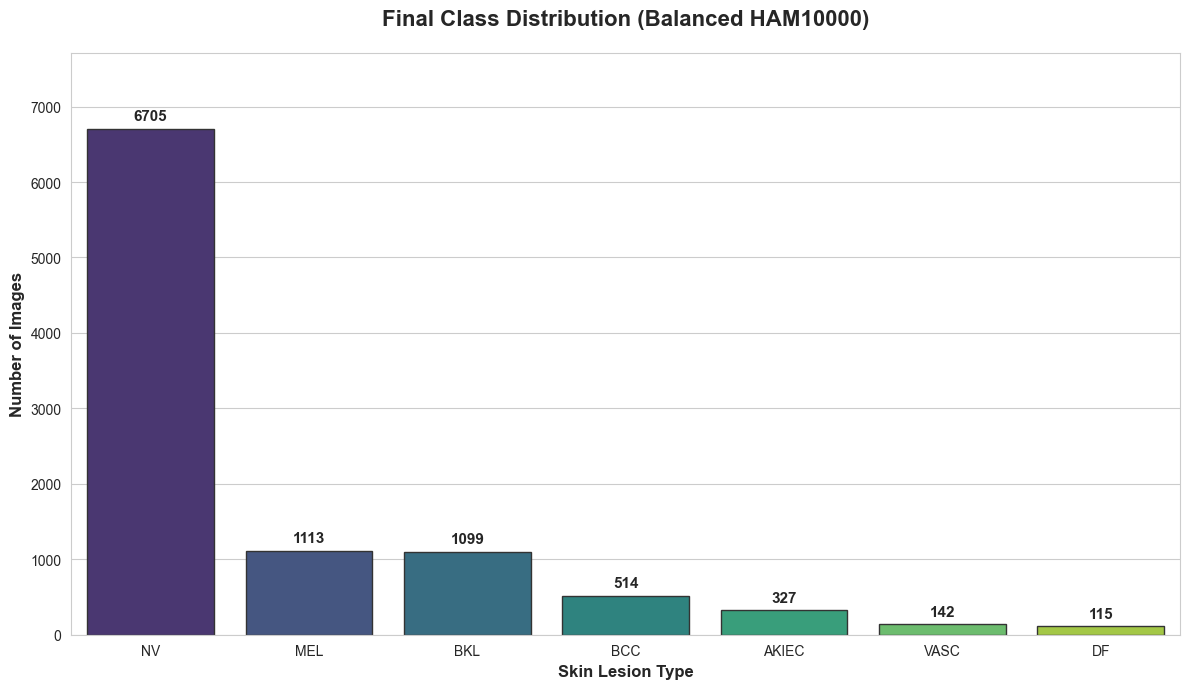

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
# Update this path to where your final balanced CSV is saved
CSV_FILE = r'C:\\Users\\sudee\\Desktop\\Notebooks\\HAM10000_dataset\\HAM10000_metadata.csv'

def plot_balanced_data(csv_path):
    # 1. Load the dataset
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: The file at {csv_path} was not found.")
        return

    # 2. Calculate counts
    # 'dx' is the standard column name for the diagnosis in HAM10000
    counts = df['dx'].value_counts().reset_index()
    counts.columns = ['Diagnosis', 'Count']
    
    # Optional: Capitalize labels for the graph
    counts['Diagnosis'] = counts['Diagnosis'].str.upper()

    # 3. Create the Visualization
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Create bar plot
    ax = sns.barplot(
        x='Diagnosis', 
        y='Count', 
        data=counts, 
        palette='viridis', 
        edgecolor='0.2'
    )

    # 4. Add value labels on top of each bar
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11,
                    fontweight='bold')

    # 5. Graph Aesthetics
    plt.title('Final Class Distribution (Balanced HAM10000)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Skin Lesion Type', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
    plt.ylim(0, counts['Count'].max() * 1.15) # Add space for labels
    
    plt.tight_layout()
    
    # 6. Show and Save
    plt.savefig('distribution_plot.png', dpi=300)
    plt.show()

# Run the function
plot_balanced_data(CSV_FILE)

*graph before agumentation*

In [7]:
import pandas as pd

# Load your dataset (replace 'metadata.csv' with your file path)
df = pd.read_csv(r'C:\Users\sudee\Desktop\Notebooks\HAM10000_balanced(224,224).csv')

# The column name is usually 'dx' in these datasets
target_classes = ['mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df', 'nv']

# Filter and count
counts = df['dx'].value_counts()

# Displaying the specific counts you requested
print("--- Sample Counts per Class ---")
for label in target_classes:
    print(f"{label.upper()}: {counts.get(label, 0)}")

--- Sample Counts per Class ---
MEL: 5000
BKL: 5000
BCC: 5000
AKIEC: 5000
VASC: 5000
DF: 5000
NV: 5000


C:\Users\sudee\AppData\Local\Temp\ipykernel_1696\4120914783.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


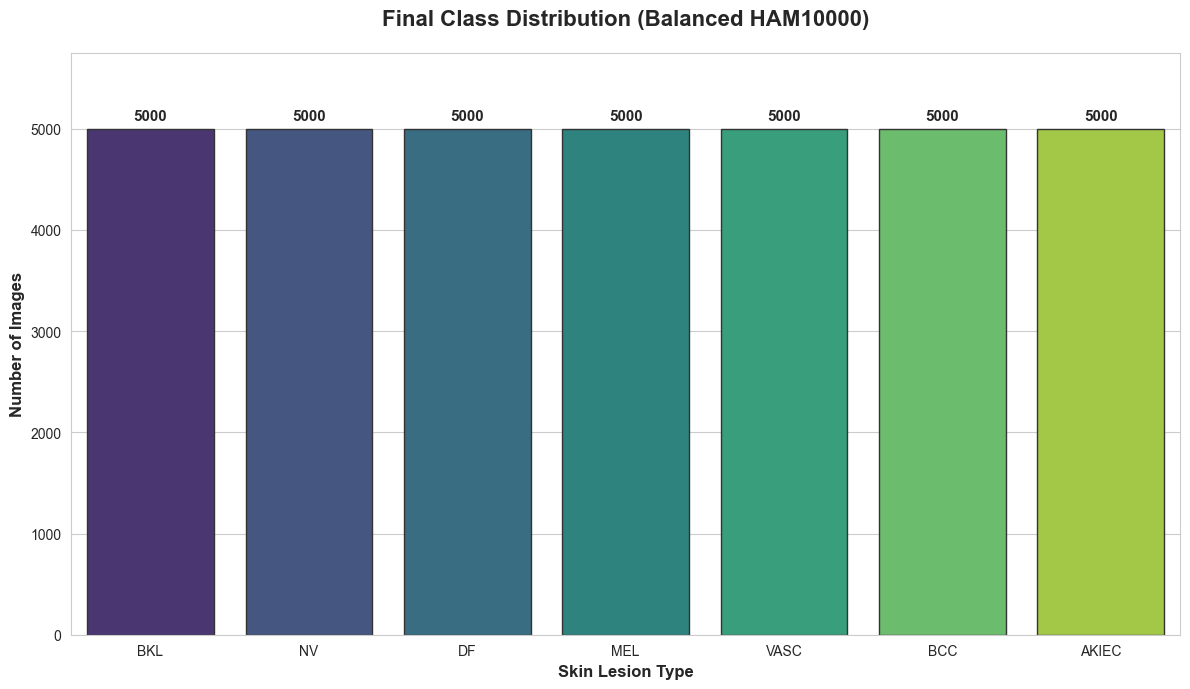

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
# Update this path to where your final balanced CSV is saved
CSV_FILE = r'C:\Users\sudee\Desktop\Notebooks\HAM10000_balanced(224,224).csv'

def plot_balanced_data(csv_path):
    # 1. Load the dataset
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: The file at {csv_path} was not found.")
        return

    # 2. Calculate counts
    # 'dx' is the standard column name for the diagnosis in HAM10000
    counts = df['dx'].value_counts().reset_index()
    counts.columns = ['Diagnosis', 'Count']
    
    # Optional: Capitalize labels for the graph
    counts['Diagnosis'] = counts['Diagnosis'].str.upper()

    # 3. Create the Visualization
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Create bar plot
    ax = sns.barplot(
        x='Diagnosis', 
        y='Count', 
        data=counts, 
        palette='viridis', 
        edgecolor='0.2'
    )

    # 4. Add value labels on top of each bar
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11,
                    fontweight='bold')

    # 5. Graph Aesthetics
    plt.title('Final Class Distribution (Balanced HAM10000)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Skin Lesion Type', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
    plt.ylim(0, counts['Count'].max() * 1.15) # Add space for labels
    
    plt.tight_layout()
    
    # 6. Show and Save
    plt.savefig('distribution_plot2.png', dpi=300)
    plt.show()

# Run the function
plot_balanced_data(CSV_FILE)

*graph after agumentation*